In [11]:
import torch
import pandas as pd
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [12]:
data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/UPB/SM7/Mineria Multimedia/Trabajo1Correcto/santander-customer-transaction-prediction/train.csv')
data

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,train_199995,0,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,...,6.1415,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661
199996,train_199996,0,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,...,4.9611,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388
199997,train_199997,0,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,...,4.0651,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995
199998,train_199998,0,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,...,2.6840,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001


In [13]:
X = data.drop(['ID_code', 'target'], axis=1).values
y = data['target'].values

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar 70% Train y 30% Temporal (para validación y test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y  # Mantiene la proporción de la clase target
)

# 2. Separar el 30% temporal en 15% Val y 15% Test (la mitad del 30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# 3. Escalar los datos (Ajustamos solo con Train para evitar fuga de datos o 'data leakage')
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Val:   {X_val.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 140000 muestras
Val:   30000 muestras
Test:  30000 muestras


In [15]:
# Convertir a tensores de PyTorch
train_data = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).unsqueeze(1))
val_data = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val).unsqueeze(1))

# DataLoaders para manejar el entrenamiento en lotes (batches)
BATCH_SIZE = 1024 # Lote grande para aprovechar procesamiento matricial
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

# Definir la Arquitectura de la Red Neuronal
class SantanderNN(nn.Module):
    def __init__(self, input_dim):
        super(SantanderNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4), # Prevención de overfitting

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 1) # Salida única para clasificación binaria
        )

    def forward(self, x):
        return self.network(x)

# Instanciar modelo, pérdida y optimizador
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SantanderNN(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss() # Combina Sigmoid + BCE numéricamente estable
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) # weight_decay es regularización L2

In [16]:
EPOCHS = 30
best_val_loss = float('inf')
patience = 5
patience_counter = 0

print("Iniciando entrenamiento...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)

    # Fase de Validación
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)

    val_loss /= len(val_loader.dataset)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Lógica de Early Stopping para evitar el sobreentrenamiento
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth') # Guardar el mejor modelo
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping activado en la época {epoch+1}. Deteniendo entrenamiento para evitar sobreentrenamiento.")
            break

Iniciando entrenamiento...
Epoch 1/30 | Train Loss: 0.3085 | Val Loss: 0.2605
Epoch 2/30 | Train Loss: 0.2396 | Val Loss: 0.2418
Epoch 3/30 | Train Loss: 0.2335 | Val Loss: 0.2445
Epoch 4/30 | Train Loss: 0.2280 | Val Loss: 0.2431
Epoch 5/30 | Train Loss: 0.2248 | Val Loss: 0.2408
Epoch 6/30 | Train Loss: 0.2208 | Val Loss: 0.2406
Epoch 7/30 | Train Loss: 0.2179 | Val Loss: 0.2385
Epoch 8/30 | Train Loss: 0.2143 | Val Loss: 0.2407
Epoch 9/30 | Train Loss: 0.2114 | Val Loss: 0.2377
Epoch 10/30 | Train Loss: 0.2085 | Val Loss: 0.2416
Epoch 11/30 | Train Loss: 0.2060 | Val Loss: 0.2389
Epoch 12/30 | Train Loss: 0.2034 | Val Loss: 0.2395
Epoch 13/30 | Train Loss: 0.2004 | Val Loss: 0.2396
Epoch 14/30 | Train Loss: 0.1981 | Val Loss: 0.2399
Early stopping activado en la época 14. Deteniendo entrenamiento para evitar sobreentrenamiento.


Generando predicciones sobre el conjunto de Testing...


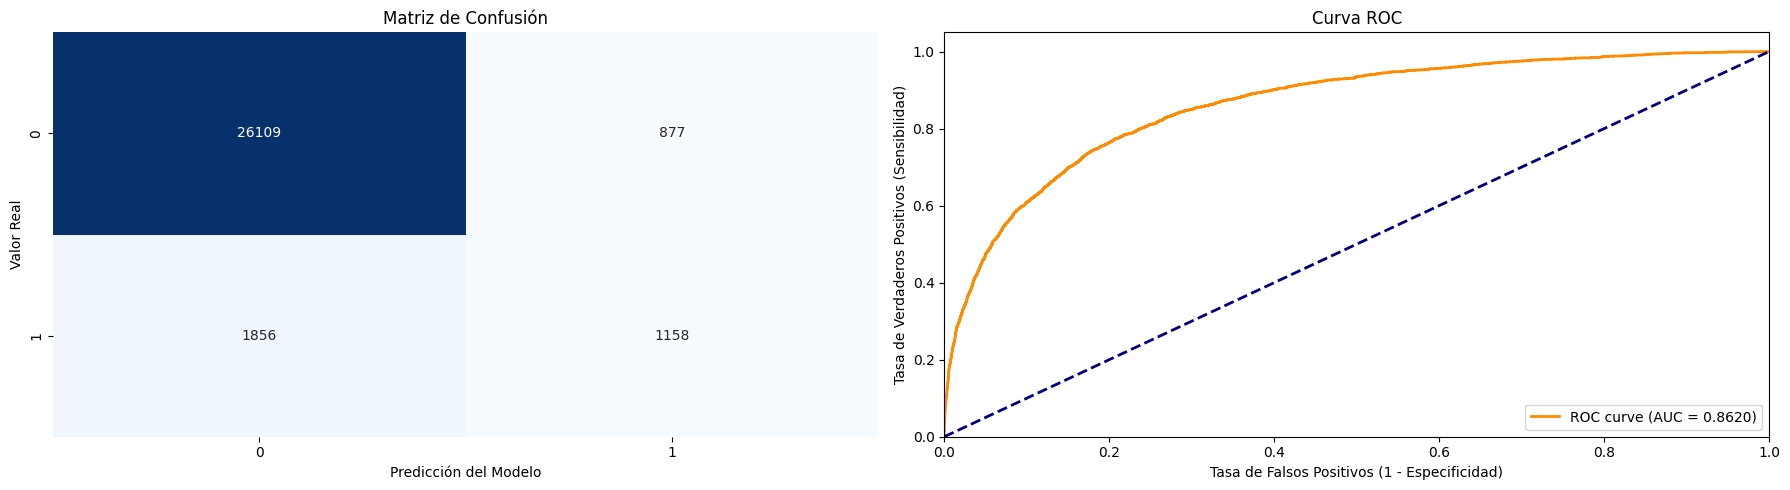


Reporte de Clasificación:
                       precision    recall  f1-score   support

Clase 0 (Mayoritaria)       0.93      0.97      0.95     26986
Clase 1 (Minoritaria)       0.57      0.38      0.46      3014

             accuracy                           0.91     30000
            macro avg       0.75      0.68      0.70     30000
         weighted avg       0.90      0.91      0.90     30000



In [17]:
# 4.1 Cargar el mejor modelo guardado
model.load_state_dict(torch.load('best_model.pth'))
model.eval() # Poner el modelo en modo evaluación (desactiva Dropout)

# Preparar datos de Test
test_data = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test).unsqueeze(1))
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

# Almacenar predicciones y valores reales
y_true = []
y_pred_probs = []

print("Generando predicciones sobre el conjunto de Testing...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        # Aplicamos Sigmoide porque usamos BCEWithLogitsLoss en el entrenamiento
        probs = torch.sigmoid(outputs).cpu().numpy()

        y_pred_probs.extend(probs)
        y_true.extend(batch_y.numpy())

y_true = np.array(y_true).flatten()
y_pred_probs = np.array(y_pred_probs).flatten()

# Convertir probabilidades a clases binarias (umbral estándar de 0.5)
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

# ---------------------------------------------------------
# 4.2 Visualización de Curvas de Aprendizaje (Pérdida)
# ---------------------------------------------------------
plt.figure(figsize=(18, 5))

# ---------------------------------------------------------
# 4.3 Matriz de Confusión (Mapa de Calor)
# ---------------------------------------------------------
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')

# ---------------------------------------------------------
# 4.4 Curva ROC (Receiver Operating Characteristic)
# ---------------------------------------------------------
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4.5 Reporte Estadístico Formal
# ---------------------------------------------------------
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred_classes, target_names=['Clase 0 (Mayoritaria)', 'Clase 1 (Minoritaria)']))

In [18]:
# 1. Calcular la distribución de clases en el conjunto de entrenamiento (X_train, y_train)
num_negativos = np.sum(y_train == 0)
num_positivos = np.sum(y_train == 1)

# 2. Calcular el peso para la clase positiva
peso_positivo = num_negativos / num_positivos

print(f"Muestras de Clase 0 (Negativos): {num_negativos}")
print(f"Muestras de Clase 1 (Positivos): {num_positivos}")
print(f"Peso asignado a la clase positiva (pos_weight): {peso_positivo:.2f}")

# 3. Convertir a un Tensor de PyTorch y enviarlo a GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight_tensor = torch.tensor([peso_positivo], dtype=torch.float32).to(device)

# 4. Redefinir la función de pérdida
criterion_balanceado = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# Importante: El optimizador y el modelo deben reiniciarse si vas a entrenar de cero
model_balanceado = SantanderNN(input_dim=X_train.shape[1]).to(device)
optimizer_balanceado = torch.optim.Adam(model_balanceado.parameters(), lr=0.001, weight_decay=1e-5)

Muestras de Clase 0 (Negativos): 125931
Muestras de Clase 1 (Positivos): 14069
Peso asignado a la clase positiva (pos_weight): 8.95


In [19]:
EPOCHS = 30
best_val_loss = float('inf')
patience = 5
patience_counter = 0

print("Iniciando entrenamiento...")
for epoch in range(EPOCHS):
    train_loss = 0.0
    model_balanceado.train() # Usar el nuevo modelo

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer_balanceado.zero_grad() # Usar el nuevo optimizador

        outputs = model_balanceado(batch_X) # Usar el nuevo modelo
        loss = criterion_balanceado(outputs, batch_y) # Usar la nueva función de pérdida

        loss.backward()
        optimizer_balanceado.step() # Usar el nuevo optimizador

        train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)

    # Fase de Validación
    model_balanceado.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model_balanceado(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)

    val_loss /= len(val_loader.dataset)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Lógica de Early Stopping para evitar el sobreentrenamiento
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_balanceado.state_dict(), 'best_model.pth') # Guardar el mejor modelo
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping activado en la época {epoch+1}. Deteniendo entrenamiento para evitar sobreentrenamiento.")
            break

Iniciando entrenamiento...
Epoch 1/30 | Train Loss: 0.9289 | Val Loss: 0.5206
Epoch 2/30 | Train Loss: 0.8402 | Val Loss: 0.4790
Epoch 3/30 | Train Loss: 0.8215 | Val Loss: 0.4882
Epoch 4/30 | Train Loss: 0.8061 | Val Loss: 0.4712
Epoch 5/30 | Train Loss: 0.7857 | Val Loss: 0.4676
Epoch 6/30 | Train Loss: 0.7723 | Val Loss: 0.4780
Epoch 7/30 | Train Loss: 0.7544 | Val Loss: 0.4442
Epoch 8/30 | Train Loss: 0.7401 | Val Loss: 0.4468
Epoch 9/30 | Train Loss: 0.7288 | Val Loss: 0.4367
Epoch 10/30 | Train Loss: 0.7100 | Val Loss: 0.4381
Epoch 11/30 | Train Loss: 0.6943 | Val Loss: 0.4229
Epoch 12/30 | Train Loss: 0.6898 | Val Loss: 0.4314
Epoch 13/30 | Train Loss: 0.6807 | Val Loss: 0.4329
Epoch 14/30 | Train Loss: 0.6677 | Val Loss: 0.4276
Epoch 15/30 | Train Loss: 0.6575 | Val Loss: 0.4168
Epoch 16/30 | Train Loss: 0.6485 | Val Loss: 0.4227
Epoch 17/30 | Train Loss: 0.6433 | Val Loss: 0.4180
Epoch 18/30 | Train Loss: 0.6316 | Val Loss: 0.4173
Epoch 19/30 | Train Loss: 0.6320 | Val Loss: 0

Generando predicciones con el Modelo Balanceado...


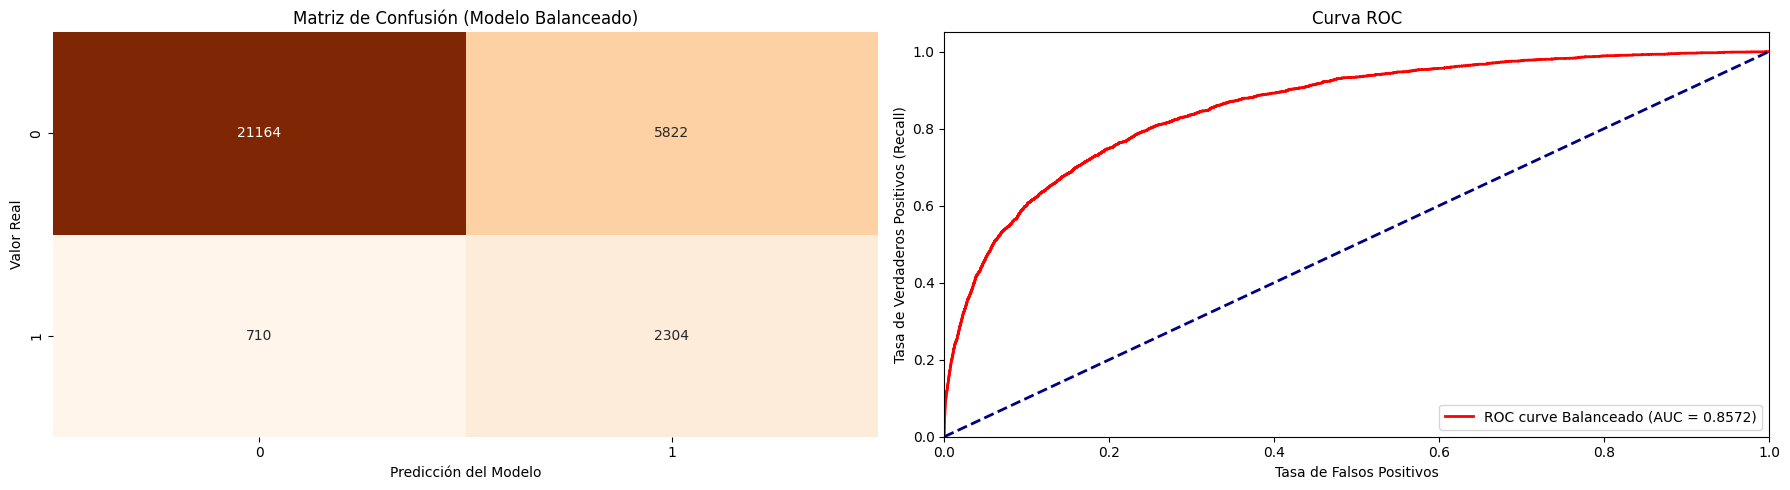


Reporte de Clasificación (MODELO BALANCEADO):
                       precision    recall  f1-score   support

Clase 0 (Mayoritaria)       0.97      0.78      0.87     26986
Clase 1 (Minoritaria)       0.28      0.76      0.41      3014

             accuracy                           0.78     30000
            macro avg       0.63      0.77      0.64     30000
         weighted avg       0.90      0.78      0.82     30000



In [20]:
# 1. Asegurarnos de que el modelo esté en modo evaluación
model_balanceado.eval()

y_pred_probs_bal = []

print("Generando predicciones con el Modelo Balanceado...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model_balanceado(batch_X)

        # Convertir logits a probabilidades con Sigmoide
        probs = torch.sigmoid(outputs).cpu().numpy()
        y_pred_probs_bal.extend(probs)

y_pred_probs_bal = np.array(y_pred_probs_bal).flatten()

# Mantenemos el umbral de decisión en 0.5
y_pred_classes_bal = (y_pred_probs_bal >= 0.5).astype(int)

# ---------------------------------------------------------
# 2. Visualización Comparativa: Matriz y Curva ROC
# ---------------------------------------------------------
plt.figure(figsize=(18, 5))

# Matriz de Confusión
plt.subplot(1, 2, 1)
cm_bal = confusion_matrix(y_true, y_pred_classes_bal)
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Oranges', cbar=False) # Usamos otro color para diferenciar
plt.title('Matriz de Confusión (Modelo Balanceado)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')

# Curva ROC
plt.subplot(1, 2, 2)
fpr_bal, tpr_bal, _ = roc_curve(y_true, y_pred_probs_bal)
roc_auc_bal = auc(fpr_bal, tpr_bal)

plt.plot(fpr_bal, tpr_bal, color='red', lw=2, label=f'ROC curve Balanceado (AUC = {roc_auc_bal:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Nuevo Reporte Estadístico
# ---------------------------------------------------------
print("\nReporte de Clasificación (MODELO BALANCEADO):")
print(classification_report(y_true, y_pred_classes_bal, target_names=['Clase 0 (Mayoritaria)', 'Clase 1 (Minoritaria)']))